In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import pymaster as nmt

### read map and mask

In [2]:
mask = hp.read_map("../masks/mask.fits")

samples = {
    "blue": hp.read_map("../galaxy_samples/1_delta.fits", field=0),
    "green": hp.read_map("../galaxy_samples/2_delta.fits", field=0),
    "red": hp.read_map("../galaxy_samples/7_delta.fits", field=0),
}

nside_gal = hp.get_nside(samples["blue"])

# ell_max = 3000
# delta_ell = 100

# b = nmt.NmtBin.from_edges(
#     np.arange(0, ell_max, delta_ell),
#     np.arange(delta_ell, ell_max + delta_ell, delta_ell)
# )

# ell_arr = b.get_effective_ells()

b = nmt.NmtBin.from_nside_linear(nside_gal, 100)

cmap = plt.cm.viridis.copy()
cmap.set_bad("gray")
cmap.set_under("white")

### compute covariances

### shot noise?

### plots

/tmp/ipykernel_734533/3752878209.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_734533/3752878209.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)


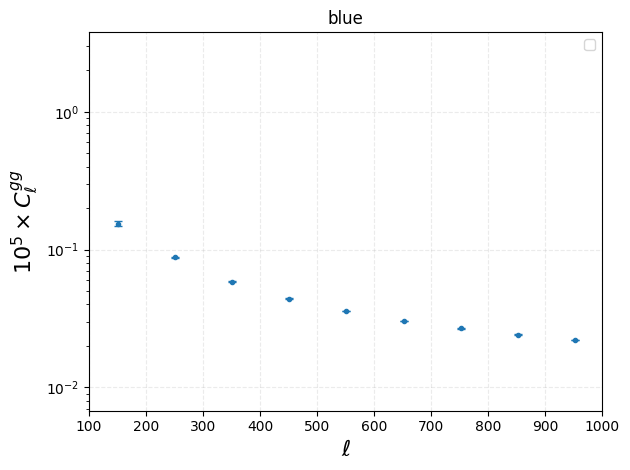

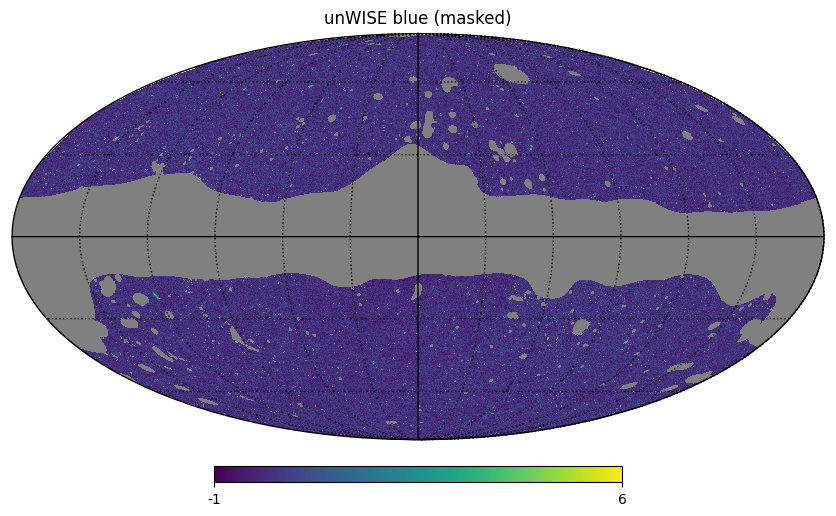

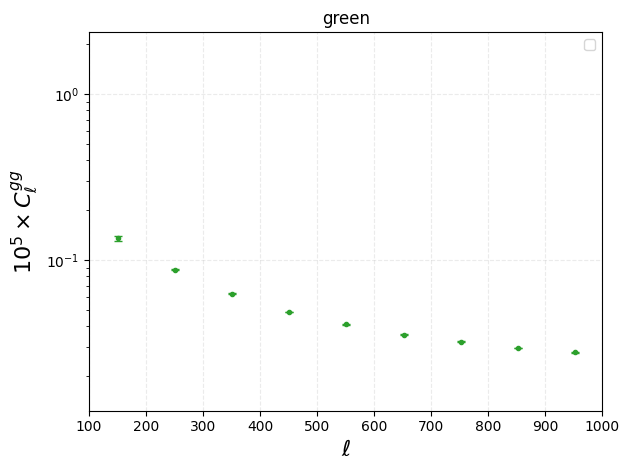

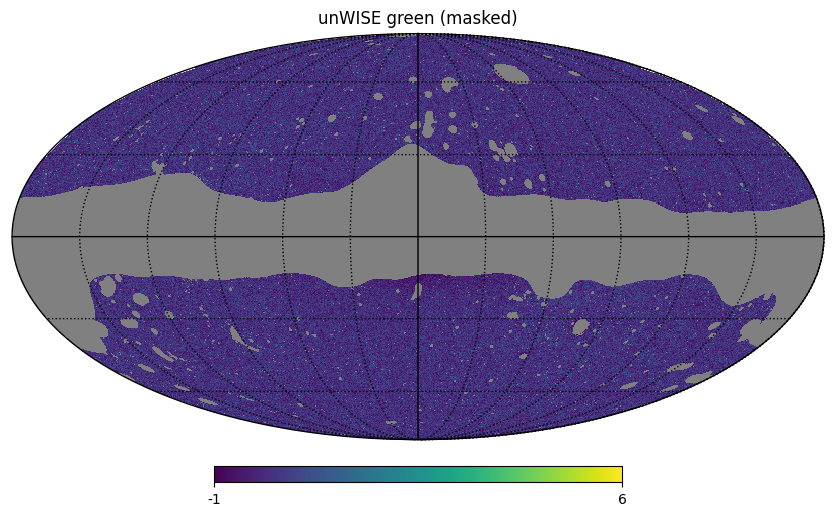

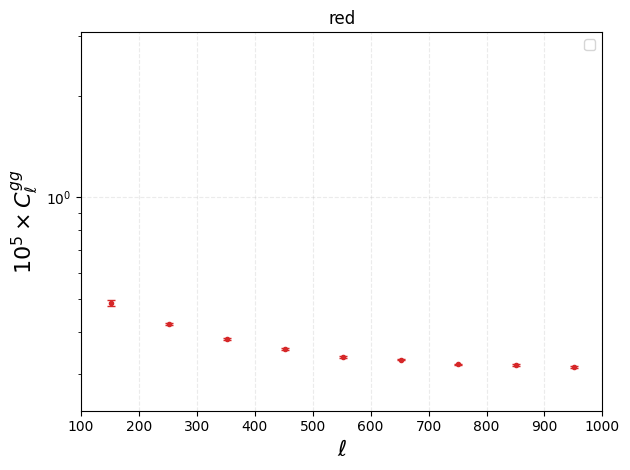

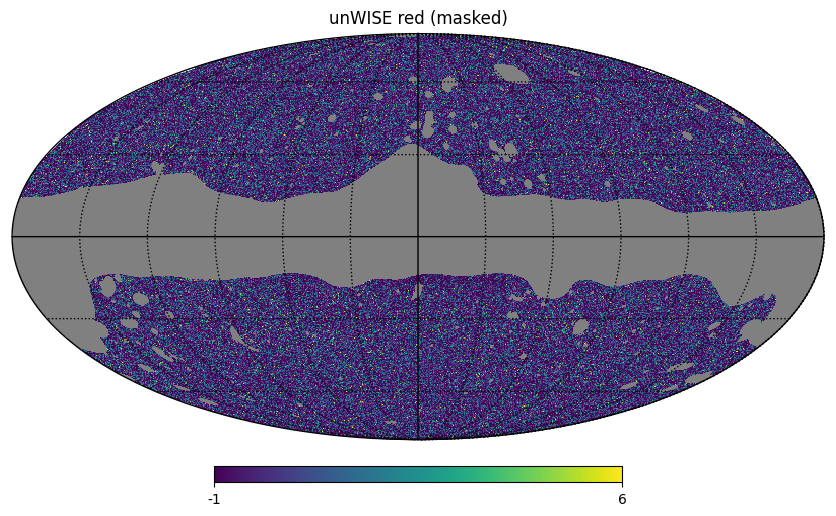

In [ ]:
samples = {
    "blue": hp.read_map("../galaxy_samples/1_delta.fits", field=0),
    "green": hp.read_map("../galaxy_samples/2_delta.fits", field=0),
    "red": hp.read_map("../galaxy_samples/7_delta.fits", field=0),
}   #create dictionary of galaxy samples

nside_gal = hp.get_nside(samples["blue"])

b = nmt.NmtBin.from_nside_linear(nside_gal, 100)    #create binning scheme for power spectrum estimation
ell_arr = b.get_effective_ells()

for label, gal_map in samples.items():

    fig, ax = plt.subplots()
    field = nmt.NmtField(mask, [gal_map])
    cl = nmt.compute_full_master(field, field, b)[0]

    colors = {
    "blue": "tab:blue",
    "green": "tab:green",
    "red": "tab:red"
    }

    w = nmt.NmtWorkspace()
    w.compute_coupling_matrix(field, field, b)

    cw = nmt.NmtCovarianceWorkspace()
    cw.compute_coupling_coefficients(field, field, field, field)

    ell_arr = b.get_effective_ells()
    ells_full = np.arange(3 * nside_gal)

    cl_full = np.interp(
    ells_full,
    ell_arr,
    cl,
    left=cl[0],
    right=cl[-1]
    )

    cl_full = cl_full.reshape(1, -1)

    cov = nmt.gaussian_covariance(
    cw,
    0, 0, 0, 0,
    cl_full,
    cl_full,
    cl_full,
    cl_full,
    w
    )

    nbins = len(ell_arr)

    cov = cov.reshape([nbins, 1, nbins, 1])[:, 0, :, 0]
    errors = np.sqrt(np.diag(cov))

    ax.errorbar(
    ell_arr,
    cl * 1e5,
    yerr=1e5 * errors,
    fmt='o',
    color=colors[label],
    markersize=3,
    capsize=3,
    elinewidth=1,
    # label=label
)
    ax.set_title(label)
    ax.legend()
    ax.set_xlim(100, 1000)
    ax.set_yscale("log")

    ax.set_xlabel(r'$\ell$', fontsize=16)
    ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

    ax.grid(True, alpha=0.25, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

    alm_gal = hp.map2alm(gal_map, lmax=3000)
    gal_map = hp.alm2map(alm_gal, lmax=3000, nside=nside_gal)
    
    gal_masked = gal_map * mask
    gal_masked = np.where(mask > 0, gal_map, hp.UNSEEN)
    hp.mollview(gal_masked, title = f"unWISE {label} (masked)", cmap = cmap, min=-1, max=6)
    hp.graticule()

    # hp.mollview(gal_masked, coord=['G','C'])
    plt.show()

In [3]:
# galaxy map
gal = hp.read_map("../galaxy_samples/1_delta.fits", field=0)
nside_gal = hp.get_nside(gal)

mask = hp.read_map("../masks/mask.fits")

### map visualisation

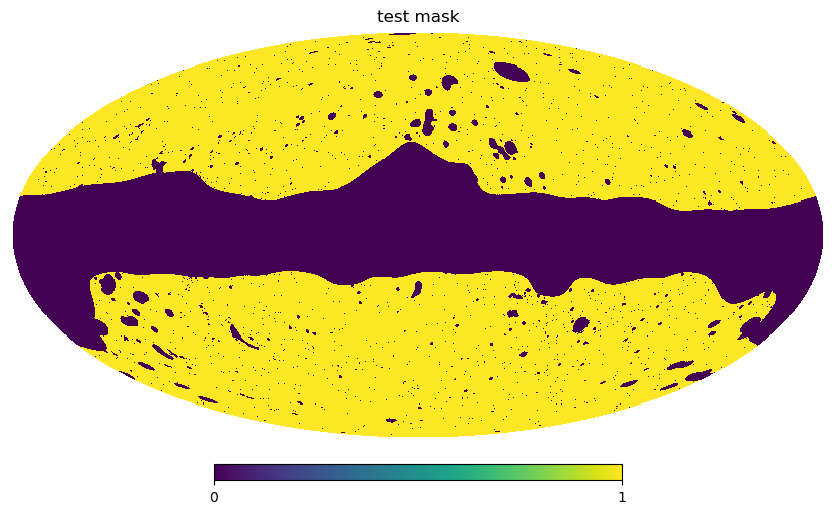

In [ ]:
# hp.mollview(mask, title="test mask")
# plt.show()

# gal_masked = gal * mask
# hp.mollview(gal_masked, title="masked galaxy map")
# plt.show()

#### compute MASTER estimator

In [4]:
b = nmt.NmtBin.from_nside_linear(nside_gal, 100)
gal_field = nmt.NmtField(mask, [gal])

cl_gal = nmt.compute_full_master(gal_field, gal_field, b)

### masking

In [13]:
cmap = plt.cm.viridis.copy()
cmap.set_bad("gray")
cmap.set_under("white")

In [10]:
alm_gal = hp.map2alm(gal_map, lmax=3000)
gal_map = hp.alm2map(alm_gal, lmax=3000, nside=nside_gal)

hp.mollview(gal_map, title="galaxy map")
plt.show()

NameError: name 'gal_map' is not defined

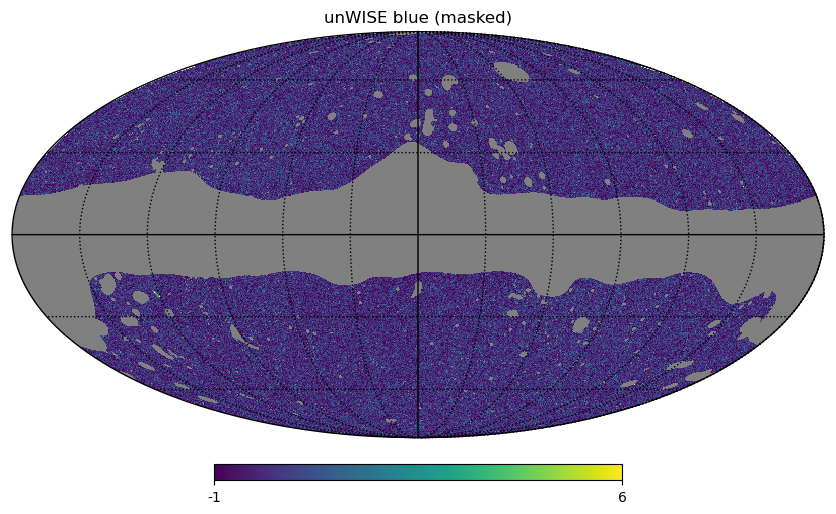

In [16]:
gal_masked = gal * mask
gal_masked = np.where(mask > 0, gal, hp.UNSEEN)
hp.mollview(
    gal_masked,
    title="unWISE blue (masked)",
    cmap = cmap, min=-1, max=6)
hp.graticule()

# hp.mollview(gal_masked, coord=['G','C'])
plt.show()

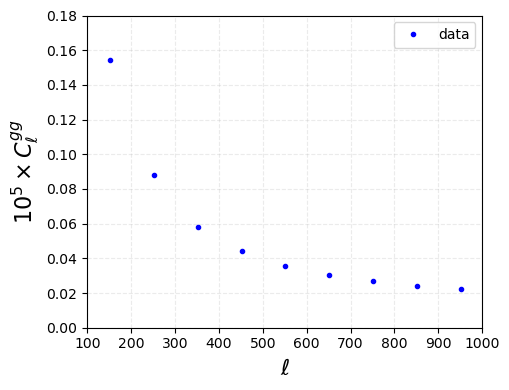

/tmp/ipykernel_710615/4233779794.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)


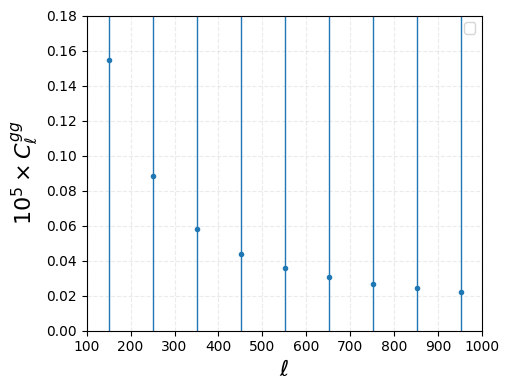

In [8]:
ell_arr = b.get_effective_ells()
cl_gg = 1e5 * cl_gal[0]

fig, ax = plt.subplots(figsize=(5.2, 4.0))

fsky = np.mean(mask**2)

delta_ell = 200  # or whatever bin width you used

errors = np.sqrt(
    2 / ((2 * ell_arr + 1) * delta_ell * fsky)
) * cl_gg

ax.errorbar(
    ell_arr,
    cl_gg,
    yerr=1e5 * errors,
    fmt='o',
    # color=colors[label],
    markersize=3,
    capsize=3,
    elinewidth=1,
    # label=label
)

ax.set_xlim(100, 1000)
ax.set_ylim(0, 0.18)

ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$10^5 \times C_\ell^{gg}$', fontsize=16)

ax.grid(True, alpha=0.25, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
field = nmt.NmtField(mask, [gal_map])

w = nmt.NmtWorkspace()
w.compute_coupling_matrix(field, field, b)

cl = nmt.compute_full_master(field, field, b)[0]

NameError: name 'gal_map' is not defined